<a href="https://colab.research.google.com/github/uvindu827/mushroom-classifer-app/blob/main/mushroom_classifier_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
from sklearn.metrics import classification_report
from sklearn.metrics._plot.confusion_matrix import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ SUCCESS: GPU is available: {gpus[0].name}")
else:
    print("❌ WARNING: You are using CPU. Go to Runtime -> Change runtime type -> T4 GPU")

✅ SUCCESS: GPU is available: /physical_device:GPU:0


#Loading data

In [3]:
dataset_path = '/content/drive/MyDrive/Mushroom-project/Sri Lankan mushroom species.v3i.folder'
BATCH_SIZE = 32
IMG_SIZE = (224, 224)


In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    f'{dataset_path}/train',
    shuffle = True,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    f'{dataset_path}/valid',
    shuffle = False,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    f'{dataset_path}/test',
    shuffle = False,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE
)

class_names = train_ds.class_names
print("\n\nMushroom classes:")
for mushroom_class in class_names:
    print(f'\t{mushroom_class}')

train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
valid_ds = valid_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Found 1251 files belonging to 13 classes.
Found 122 files belonging to 13 classes.
Found 61 files belonging to 13 classes.


Mushroom classes:
	Idalolu
	Muthu beli bimmal
	boththam hathu
	goma hathu
	heenvali hathu
	kotan hathu
	kurulu thuda bimmal
	leena hathu
	mahaveli hathu
	nayi hathu
	piduru hathu
	rathu hathu
	uru hathu


#Data Augmentation

In [5]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])

#Model Architecture

In [6]:
base_model = tf.keras.applications.MobileNetV3Small(
    input_shape = IMG_SIZE + (3,),
    include_top = False,
    weights = 'imagenet'
)

base_model.trainable = False

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v3.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(len(class_names), activation='softmax')(x)

model = models.Model(inputs, outputs)

In [8]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [9]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [10]:
history = model.fit(
    train_ds,
    validation_data = valid_ds,
    epochs = 40,
    callbacks = [early_stopping]
)

Epoch 1/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 191s 4s/step - accuracy: 0.1408 - loss: 2.8655 - val_accuracy: 0.3689 - val_loss: 1.9553
Epoch 2/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.4807 - loss: 1.6596 - val_accuracy: 0.5574 - val_loss: 1.4306
Epoch 3/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6666 - loss: 1.1754 - val_accuracy: 0.6475 - val_loss: 1.1666
Epoch 4/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7589 - loss: 0.9127 - val_accuracy: 0.7131 - val_loss: 1.0496
Epoch 5/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7789 - loss: 0.7722 - val_accuracy: 0.7213 - val_loss: 0.9720
Epoch 6/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8221 - loss: 0.6808 - val_accuracy: 0.7459 - val_loss: 0.8907
Epoch 7/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8526 - loss: 0.5767 - val_accuracy: 0.7459 - val_loss: 0.8817
Epoch 8/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8582 - loss: 0.5347 - val_accuracy: 0.7377 - v

#Evaluation

In [11]:
pred = model.predict(test_ds)
y_pred = np.argmax(pred, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 5s/step


In [12]:
y_true = []

for images, labels in test_ds:
  y_true.extend(labels.numpy())



- Classification report

In [13]:
cr = classification_report(y_true, y_pred)
print(cr)

              precision    recall  f1-score   support

           0       1.00      0.67      0.80         6
           1       0.67      0.67      0.67         3
           2       1.00      1.00      1.00         2
           3       1.00      0.83      0.91        12
           4       0.50      0.75      0.60         4
           5       0.86      0.86      0.86         7
           6       1.00      1.00      1.00         2
           7       0.00      0.00      0.00         1
           8       1.00      0.50      0.67         4
           9       1.00      1.00      1.00         7
          10       0.57      1.00      0.73         4
          11       1.00      1.00      1.00         5
          12       0.67      1.00      0.80         4

    accuracy                           0.84        61
   macro avg       0.79      0.79      0.77        61
weighted avg       0.87      0.84      0.83        61



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


- Confusion matrix

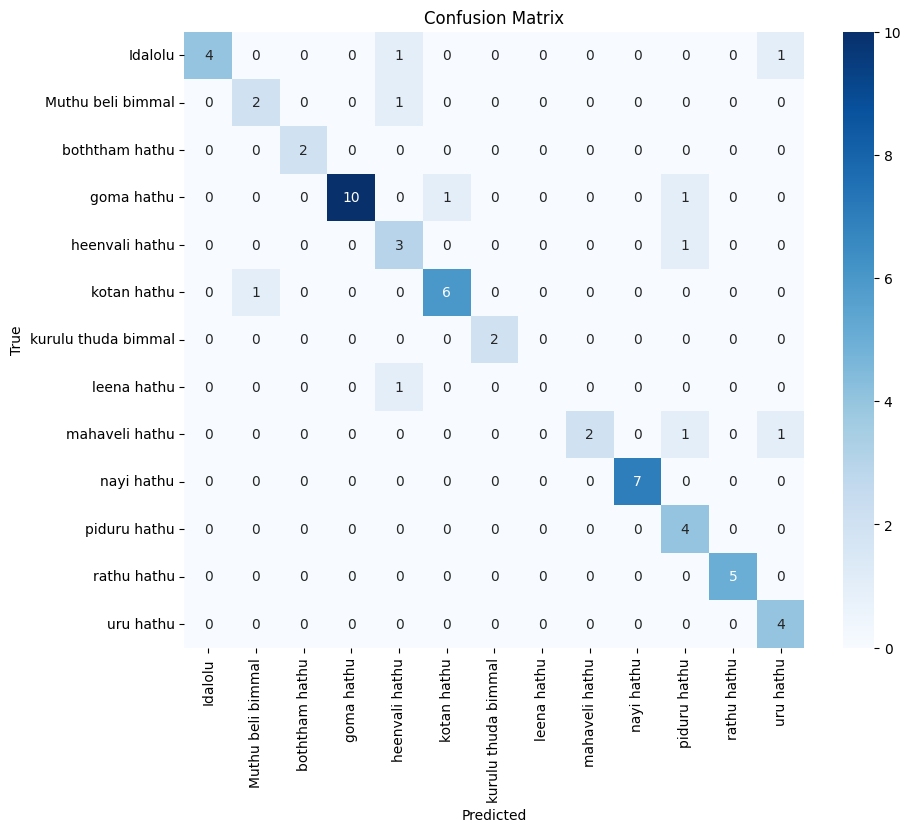

In [14]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

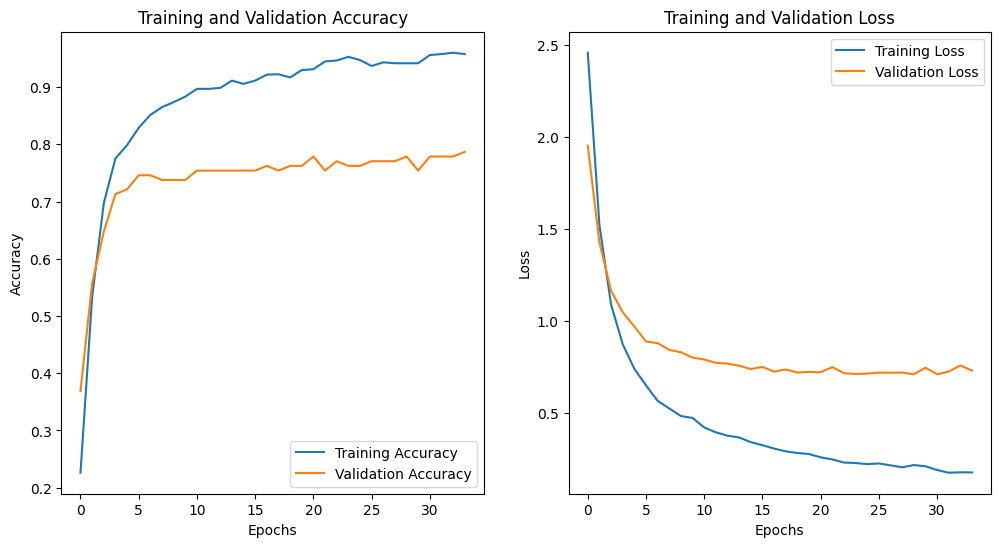

In [15]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

# 2. Setup the plot
plt.figure(figsize=(12, 6))

# --- Plot Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# --- Plot Loss ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.show()